The concept: X-ray sensors are imperfect. They randomly corrupt individual pixels — some go pure white (salt), some go pure black (pepper). A regular blur filter averages these extremes into the image making edges soft. A median filter is smarter — it sorts the neighbourhood values and picks the middle one, so extreme outliers (0 and 255) never win. Edges stay sharp.


In [ ]:
# ============================================================
# CELL 1: SETUP — Run this first every session
# ============================================================
!pip install medmnist -q

from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/DIP_Lab1/outputs', exist_ok=True)
print("✅ Setup complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.9 MB/s eta 0:00:00
Mounted at /content/drive
✅ Setup complete!


In [ ]:
# ============================================================
# CELL 2: IMPORTS AND LOAD IMAGE
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from medmnist import PneumoniaMNIST

# Load the same dataset — using a DIFFERENT image this time (index 5)
# so your Exercise 2 output looks distinct from Exercise 1
dataset = PneumoniaMNIST(split='test', download=True, size=128)

sample_image, label = dataset[5]
original = np.array(sample_image)

if original.ndim == 3:
    original = original[:, :, 0]

print(f"✅ Image loaded")
print(f"   Shape  : {original.shape}")
print(f"   Dtype  : {original.dtype}")
print(f"   Range  : {original.min()} to {original.max()}")
print(f"   Label  : {'Pneumonia' if label[0]==1 else 'Normal'}")

100%|██████████| 75.5M/75.5M [00:04<00:00, 15.8MB/s]


✅ Image loaded
   Shape  : (128, 128)
   Dtype  : uint8
   Range  : 73 to 196
   Label  : Pneumonia


 Why copy first? If you modify original directly, you lose your clean reference image and can't compare. Always work on a copy when doing destructive operations. This is a professional habit in image processing.

In [ ]:
# ============================================================
# CELL 3: ADD SALT-AND-PEPPER NOISE
# ============================================================
# OpenCV has no built-in S&P noise function — we write it ourselves
# This is actually a learning opportunity: you understand EXACTLY
# what the noise is doing at the pixel level

def add_salt_pepper(image, noise_level=0.05):
    """
    Corrupts an image with salt-and-pepper noise.

    noise_level = 0.05 means 5% of ALL pixels get corrupted:
      - Half become 255 (white  = 'salt')
      - Half become 0   (black = 'pepper')

    In medical imaging this mimics:
      - Dead sensor pixels (always black)
      - Saturated sensor pixels (always white)
    """
    noisy = image.copy()                        # Never modify the original!
    total_pixels = image.size                   # e.g. 128x128 = 16,384 pixels
    n_corrupt = int(total_pixels * noise_level) # 5% of 16,384 = 819 pixels

    # SALT: pick random coordinates, set them to 255 (white)
    salt_rows = np.random.randint(0, image.shape[0], n_corrupt // 2)
    salt_cols = np.random.randint(0, image.shape[1], n_corrupt // 2)
    noisy[salt_rows, salt_cols] = 255

    # PEPPER: pick random coordinates, set them to 0 (black)
    pepper_rows = np.random.randint(0, image.shape[0], n_corrupt // 2)
    pepper_cols = np.random.randint(0, image.shape[1], n_corrupt // 2)
    noisy[pepper_rows, pepper_cols] = 0

    return noisy

# Apply at 5% corruption level
noisy = add_salt_pepper(original, noise_level=0.05)

corrupted = int(original.size * 0.05)
print(f"✅ Noise added — {corrupted} pixels corrupted out of {original.size}")

✅ Noise added — 819 pixels corrupted out of 16384


In [ ]:
# ============================================================
# CELL 4: APPLY BOTH FILTERS FOR COMPARISON
# ============================================================

# --- MEDIAN FILTER ---
# Looks at each 3x3 neighbourhood (9 pixels)
# Sorts their values: [0, 45, 112, 134, 140, 145, 198, 210, 255]
# Picks the MIDDLE value: 140
# The 0 (pepper) and 255 (salt) are at the ends — they never get picked!
# Result: noise removed, edges preserved
denoised_median = cv2.medianBlur(noisy, ksize=3)

# --- GAUSSIAN BLUR (for comparison) ---
# Computes a WEIGHTED AVERAGE of the neighbourhood
# A salt pixel (255) drags the average UP
# A pepper pixel (0) drags the average DOWN
# Result: noise partially removed BUT edges get blurry too
denoised_gaussian = cv2.GaussianBlur(noisy, (3, 3), sigmaX=1)

print("✅ Median filter applied  (ksize=3)")
print("✅ Gaussian blur applied  (kernel=3x3, sigma=1)")
print()
print("Compare these two — median should look much cleaner on edges")

✅ Median filter applied  (ksize=3)
✅ Gaussian blur applied  (kernel=3x3, sigma=1)

Compare these two — median should look much cleaner on edges


Median filtering is non-linear (it sorts). Gaussian filtering is linear (it averages). Sorting is what makes median filtering immune to outliers — and salt/pepper pixels ARE outliers by definition.

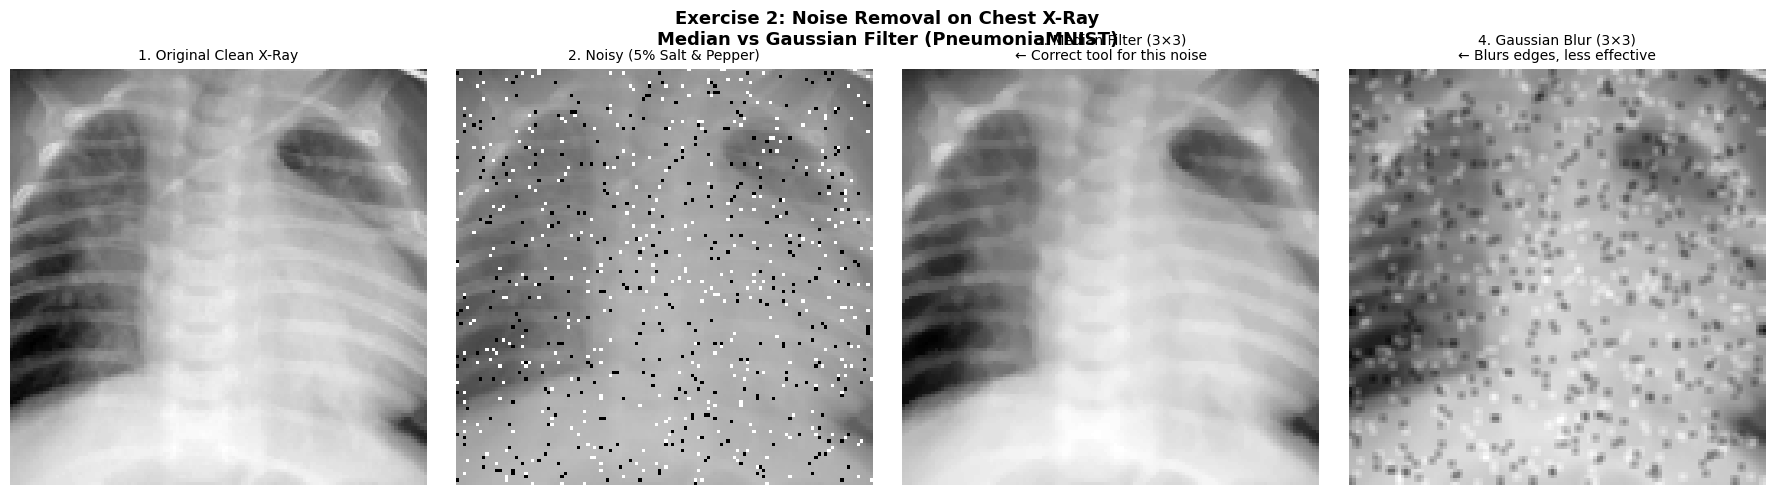

✅ Figure saved to: /content/drive/MyDrive/DIP_Lab1/outputs/exercise2_output.png


In [ ]:
# ============================================================
# CELL 5: DISPLAY AND SAVE 4-PANEL COMPARISON
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Exercise 2: Noise Removal on Chest X-Ray\n'
             'Median vs Gaussian Filter (PneumoniaMNIST)',
             fontsize=13, fontweight='bold')

panels = [
    (original,          '1. Original Clean X-Ray'),
    (noisy,             '2. Noisy (5% Salt & Pepper)'),
    (denoised_median,   '3. Median Filter (3×3)\n← Correct tool for this noise'),
    (denoised_gaussian, '4. Gaussian Blur (3×3)\n← Blurs edges, less effective'),
]

for ax, (img, title) in zip(axes, panels):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()

save_path = '/content/drive/MyDrive/DIP_Lab1/outputs/exercise2_output.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Figure saved to: {save_path}")

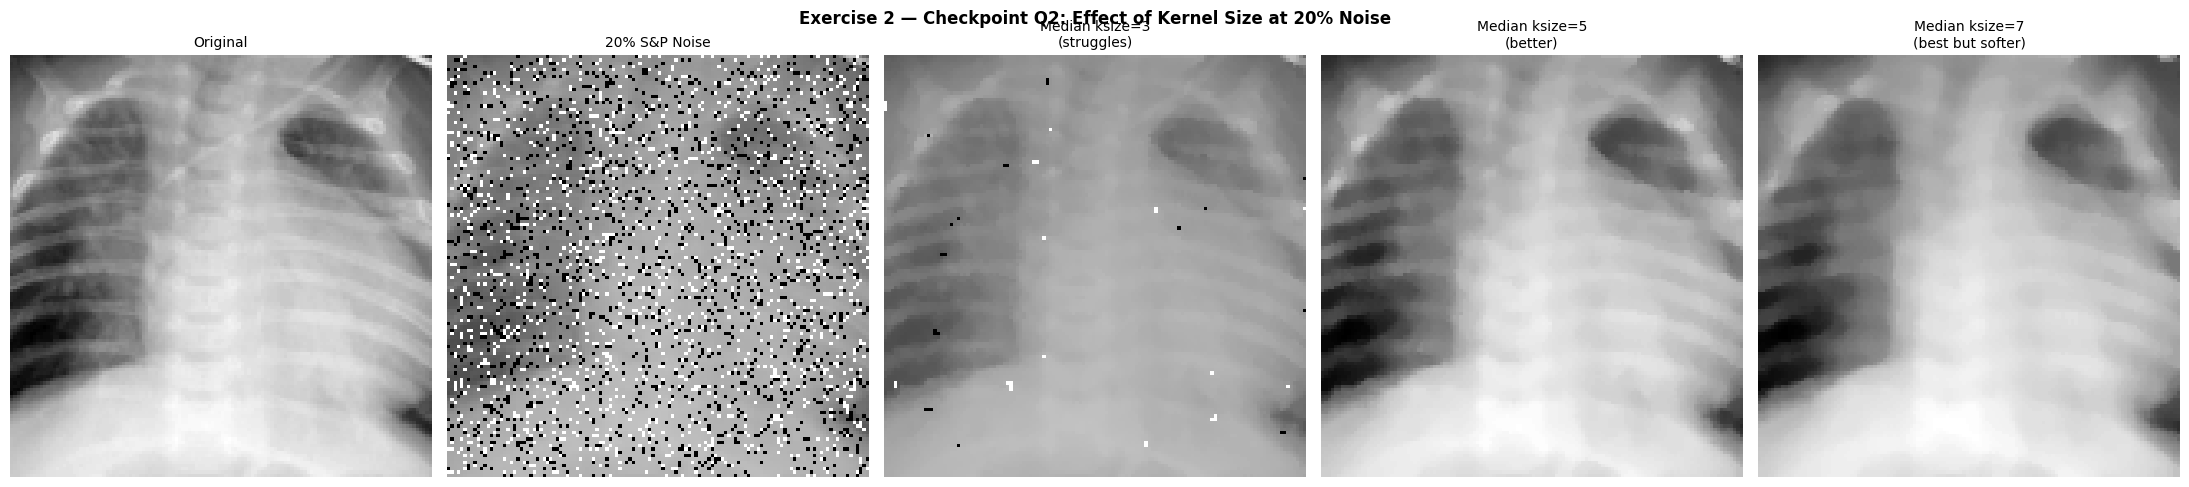

✅ Noise experiment saved


In [ ]:
# ============================================================
# CELL 6: EXPERIMENT — What happens at 20% noise?
# ============================================================
# The lab asks: can a 3x3 median still clean 20% noise?
# Let's test ksize=3, 5, and 7 at 20% corruption

noisy_heavy = add_salt_pepper(original, noise_level=0.20)

median_3 = cv2.medianBlur(noisy_heavy, ksize=3)
median_5 = cv2.medianBlur(noisy_heavy, ksize=5)
median_7 = cv2.medianBlur(noisy_heavy, ksize=7)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Exercise 2 — Checkpoint Q2: Effect of Kernel Size at 20% Noise',
             fontsize=12, fontweight='bold')

panels = [
    (original,      'Original'),
    (noisy_heavy,   '20% S&P Noise'),
    (median_3,      'Median ksize=3\n(struggles)'),
    (median_5,      'Median ksize=5\n(better)'),
    (median_7,      'Median ksize=7\n(best but softer)'),
]

for ax, (img, title) in zip(axes, panels):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DIP_Lab1/outputs/exercise2_noise_experiment.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Noise experiment saved")

In [ ]:
# ============================================================
# CELL 7: CHECKPOINT QUESTIONS — EXERCISE 2
# ============================================================

"""
Q1: Compare Panel 3 (Median) and Panel 4 (Gaussian).
    Which one better preserves the sharp edges of the X-ray structures?

ANSWER: Panel 3 (Median) preserves sharp edges significantly better.
The lung boundaries, rib outlines and diaphragm edges remain crisp
after median filtering. Panel 4 (Gaussian) removes some noise but
simultaneously blurs those same edges — making the image look smooth
but diagnostically less useful. In medical imaging, edge preservation
is critical: a radiologist needs sharp lung borders to detect conditions
like pneumothorax or pleural effusion.

--------------------------------------------------------------------

Q2: What happens at 20% noise? Can ksize=3 still clean the image?

ANSWER: At 20% corruption, ksize=3 struggles — some noise pixels remain
because with heavy corruption, a 3x3 neighbourhood (9 pixels) may contain
MULTIPLE noise pixels and the median itself gets skewed. ksize=5 recovers
the image much better. ksize=7 removes virtually all noise but introduces
slight blurring of fine lung detail. The tradeoff is: larger kernel =
better noise removal but more edge softening.

--------------------------------------------------------------------

Q3: Why is Gaussian blurring less suitable than median filtering
    for salt-and-pepper noise? (Mathematical reason)

ANSWER: Gaussian blur computes a WEIGHTED AVERAGE of pixel values in
the neighbourhood. Because salt (255) and pepper (0) are extreme values,
they directly shift the average — a single white noise pixel in a dark
region pulls the average brighter. The median, being an ORDER STATISTIC
rather than an average, is immune to outliers: extreme values sort to
the ends of the ranked list and are never selected as the median. This
makes median filtering statistically robust to impulsive noise while
Gaussian blur is not.
"""

print("✅ Checkpoint answers recorded for Exercise 2")




✅ Checkpoint answers recorded for Exercise 2
